> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

# 2D Axisymmetric Heat Diffusion — Mole Perturbation (Forward Problem)

Every previous notebook modelled the soil as a 1D column — temperature varying only with depth and time. That assumption breaks down in the immediate vicinity of the HP³ mole. The aluminium mole (k_Al ≈ 200 W/m·K) is roughly 5000 times more thermally conductive than the surrounding regolith (k_soil ≈ 0.039 W/m·K). During the day, it acts as a thermal fin — pumping heat downward from the hot shallow soil to the cold deep soil. At night, the gradient reverses and it pumps heat back up. This inflates the mole's temperature amplitude beyond what any 1D passive-soil model can predict, and is the core reason the spatial average PINN recovered $\kappa \approx 6.3 \times 10^{-8}$ m²/s instead of Spohn's $3.93 \times 10^{-8}$ m²/s. To do better, we must model the temperature field in the soil *around* the mole.

---

## Geometry and Coordinate System

The mole is approximated as a vertical cylinder. Its real 30° tilt is projected onto the vertical axis following Spohn's approach — a standard simplification that preserves the dominant physics. Because the cylinder is vertical, the temperature field is symmetric around its axis. There is no angular variation, so the 3D problem collapses to 2D.

The PINN takes **(r, z, t)** as inputs and outputs **T(r, z, t)**:

- $r$ = radial distance from the mole's central axis
- $z$ = depth below the surface
- $t$ = time within a single Martian sol

---

## Governing PDE — Cylindrical Heat Equation

The heat equation in cylindrical coordinates with axisymmetry is:

$$\frac{\partial T}{\partial t} = \kappa \left(\frac{\partial^2 T}{\partial r^2} + \frac{1}{r}\frac{\partial T}{\partial r} + \frac{\partial^2 T}{\partial z^2}\right)$$

**Where:**
- $\frac{\partial^2 T}{\partial r^2}$ = radial curvature — heat diffusing inward and outward from the mole
- $\frac{1}{r}\frac{\partial T}{\partial r}$ = the **geometric correction term** — in cylindrical geometry, a shell at larger $r$ has more surface area, so heat spreads faster radially than in Cartesian coordinates. This term accounts for that asymmetry. It vanishes as $r \to \infty$, recovering the flat Cartesian case
- $\frac{\partial^2 T}{\partial z^2}$ = vertical diffusion — same as the 1D notebooks
- $\kappa = 3.93 \times 10^{-8}\ \text{m}^2/\text{s}$ = fixed at Spohn's value for this forward validation run

There is no singularity at $r = 0$ because the domain begins at $r = R_\text{mole} = 1.35\ \text{cm}$ — the physical mole surface. We never evaluate the PDE at the axis itself.

---

## Domain

| Dimension | Range |
|---|---|
| $r$ | $R_\text{mole} = 1.35\ \text{cm}$ to $r_\text{max} = 25\ \text{cm}$ |
| $z$ | $0$ (surface) to $z_\text{max} = 0.4\ \text{m}$ |
| $t$ | $0$ to one sol ($88775.244\ \text{s}$) |

$r_\text{max} = 25\ \text{cm}$ is roughly 5–10 skin depths from the mole surface — far enough that the mole's thermal perturbation has fully decayed and the soil looks undisturbed.

---

## Boundary Conditions — Four Walls

This is the most important architectural decision in the notebook. All observed data is promoted to boundary conditions. There is no separate data loss term.

**1. Surface** ($z = 0$, all $r$, all $t$): RAD Sol 511 radiometer data — the diurnal surface temperature forcing. Identical to the 1D notebooks.

**2. Deep bottom** ($z = z_\text{max}$, all $r$, all $t$): Fixed at $T = 225.6\ \text{K}$ — the mean temperature at depth where the diurnal signal has vanished.

**3. Mole surface** ($r = R_\text{mole}$, $z \in [z_0, z_1]$, all $t$): TEM-A Sol 1202 data applied as a **Dirichlet BC**. The mole is isothermal at each instant in time — $k_\text{Al} \gg k_\text{soil}$ means every point along the mole shares the same temperature $T_\text{mole}(t)$. This is a key architectural upgrade from the 1D notebooks: TEM-A was previously a data loss term living *inside* the domain. Here it becomes a hard boundary condition on the mole's cylindrical surface.

**4. Far field** ($r = r_\text{max}$, all $z$, all $t$): A **Neumann condition** $\frac{\partial T}{\partial r} = 0$ — the temperature gradient is zero at the far boundary, meaning no heat flux crosses it. This encodes the assumption that the mole's perturbation has fully decayed by $r = 25\ \text{cm}$ and the undisturbed soil has no net radial flux.

---

## This is the Forward Problem

$\kappa$ is fixed at Spohn's value. The network learns $T(r, z, t)$ alone. The purpose is purely validation: does the 2D setup produce a physically sensible field? Does the perturbation decay radially? Is the mole BC respected? Does the far field approach the 1D solution? Only once these checks pass does it make sense to flip to the inverse problem and make $\kappa$ learnable.

In [1]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
z_min = 0             # surface
z_max = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

R_mole = 0.0135       # Radius of the mole
r_max = 0.25          # Max distance from mole center

z_0 = 0.017           # Top of mole
z_1 = 0.363           # bottom of mole

avg_bottom_temp = 225.6  # average bottom temperature (K)


# Import fourier coefficients for amalytical solutions at the boundaries

import pickle

with open('../../resources/data/fourier_coefficients.pkl', 'rb') as f:
    coeffs = pickle.load(f)


# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


key = random.PRNGKey(0)
key, key1, key2, key3, key4, key5, key6 = random.split(key, 7)

# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)
r_bc_surface = random.uniform(key3, (n_surface, 1), minval=R_mole, maxval=r_max)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = random.uniform(key5, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * z_max
r_bc_bottom = random.uniform(key4, (n_surface, 1), minval=R_mole, maxval=r_max)

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)


# Mole surface boundary (r = r_mole)

N_z_mole = 20
N_t_mole = len(ltst_mole)

z_mole_1d = jnp.linspace(z_0, z_1, N_z_mole)
t_mole_1d = jnp.array(ltst_mole)

Z_mole, T_mole_grid = jnp.meshgrid(z_mole_1d, t_mole_1d, indexing='ij')
# Z_mole shape: (20, 200), T_mole_grid shape: (20, 200)

x_bc_mole = Z_mole.flatten().reshape(-1, 1)        # (4000, 1)
t_bc_mole = T_mole_grid.flatten().reshape(-1, 1)    # (4000, 1)
r_bc_mole = jnp.ones_like(x_bc_mole) * R_mole       # (4000, 1)

# Temperature: T_mole depends only on t, not z (isothermal)
# Need to repeat temp_mole for each z point
temp_mole_arr = jnp.array(temp_mole)  # (200,)
u_bc_mole = jnp.tile(temp_mole_arr, N_z_mole).reshape(-1, 1)  # (4000, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom, t_bc_mole])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom, x_bc_mole])
r_bc = jnp.concatenate([r_bc_surface, r_bc_bottom, r_bc_mole])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom, u_bc_mole])

# Rmax boundary

key1, key7, key8 = random.split(key1, 3)
n_far = 2000

t_bc_far = random.uniform(key7, (n_far, 1), minval=0, maxval=sol_seconds)
x_bc_far = random.uniform(key8, (n_far, 1), minval=0, maxval=z_max * 0.6)
# r_bc_far = jnp.ones((n_far, 1)) * r_max

# 2. Physics collocation points (30 * 30 * 30 = 9000 points)
t_physics = random.uniform(key1, (9000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (9000, 1), minval=0, maxval=z_max)
r_physics = random.uniform(key6, (9000, 1), minval=R_mole, maxval=r_max)



# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_max
r_min, r_norm_max = R_mole, r_max
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_r(r): return ( r - r_min) / (r_norm_max - r_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
r_bc = normalize_r(r_bc)
u_bc = normalize_u(u_bc)

t_bc_far_norm = normalize_t(t_bc_far)
x_bc_far_norm = normalize_x(x_bc_far)
# r_bc_far_norm = normalize_r(r_bc_far)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)
r_physics = normalize_r(r_physics)


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, r_point, kappa):

    def u(t_val, x_val, r_val):
        txr_in = jnp.array([[t_val, x_val, r_val]])
        return network(params, txr_in)[0, 0]

    # Derivatives w.r.t. NORMALIZED inputs
    du_dt = grad(u, argnums=0)(t_point, x_point, r_point)
    du_dr = grad(u, argnums=2)(t_point, x_point, r_point)
    d2u_dr2 = grad(grad(u, argnums=2), argnums=2)(t_point, x_point, r_point)
    d2u_dx2 = grad(grad(u, argnums=1), argnums=1)(t_point, x_point, r_point)

    # Scale factors (physical ranges)
    dt = t_max - t_min          # 88775.244
    dz = x_max - x_min          # 0.4
    dr = r_max - R_mole          # 0.2365

    # Physical r from normalized r: r_phys = R_mole + r_norm * Δr
    r_phys = R_mole + r_point * dr

    # PDE residual (divided by κ, your week 8 trick):
    # (1/κ) * (dT_n/dt_n)/Δt - (d²T_n/dr_n²)/Δr² - (1/r_phys)*(dT_n/dr_n)/Δr - (d²T_n/dz_n²)/Δz²

    kappa_dt = kappa * dt
    residual = (du_dt  - (d2u_dr2 / dr**2) * kappa_dt - ((1.0 / r_phys) * du_dr / dr) * kappa_dt - kappa_dt * (d2u_dx2 / dz**2))

    return residual

# Analytical solution at r max


# dirichlet boundary that enforces analytucal solution
# def make_analytical_solution(A_n, phi_n, T_mean, N_harmonics, omega):
#     """Now kappa is NOT baked in — it's a runtime argument."""
#     n_vals = jnp.arange(1, N_harmonics + 1)
#     An = A_n[1:N_harmonics + 1]
#     phin = phi_n[1:N_harmonics + 1]

#     @jit
#     def T_analytical(t, z, kappa):
#         # Skin depths recomputed each call using current kappa
#         delta_n = jnp.sqrt(2 * kappa / (n_vals * omega))
#         u_far = T_mean + jnp.sum(
#             An * jnp.exp(-z / delta_n) * jnp.cos(n_vals * omega * t - z / delta_n + phin)
#         )

#         return normalize_u(u_far)

#     return T_analytical


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params and kappa_eff fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, 0, None))

# Add this function
def neumann_far_single(params, t_point, x_point):
    """∂T/∂r = 0 at r = r_max (normalized r = 1)"""
    def u(r_val):
        txr_in = jnp.array([[t_point, x_point, r_val]])
        return network(params, txr_in)[0, 0]

    du_dr = grad(u)(1.0)  # evaluate at r_norm = 1
    return du_dr

neumann_far_batch = vmap(neumann_far_single, in_axes=(None, 0, 0))

# T_far = make_analytical_solution(
#     jnp.array(coeffs['A_n']),
#     jnp.array(coeffs['phi_n']),
#     coeffs['T_mean'],
#     coeffs['N_harmonics'],
#     coeffs['omega']
# )

# T_sol_batch = vmap(T_far, in_axes=(0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [3, 64, 64, 64, 64, 1]  # 3 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={30000: 0.1})
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, r_bc, u_bc, t_bc_far, x_bc_far, t_physics, x_physics, r_physics, kappa):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        txr_bc = jnp.concatenate([t_bc, x_bc, r_bc], axis=1)

        u_pred_bc = network(params, txr_bc)
        bc_loss_core = jnp.mean((u_pred_bc - u_bc)**2)

        # Boundary condition at r_max

        # u_far = T_sol_batch(t_bc_far, x_bc_far, kappa)
        # u_pred_far = network(params, txr_far_norm)
        du_dr_far = neumann_far_batch(params,
                                   t_bc_far_norm.ravel(),
                                   x_bc_far_norm.ravel())
        bc_loss_far = jnp.mean(du_dr_far**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(),
                                                x_physics.ravel(),
                                                r_physics.ravel(),
                                                kappa)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.


        return  bc_loss_core * 50 + physics_loss + bc_loss_far, (bc_loss_core, physics_loss, bc_loss_far)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 60000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# txr_far_norm = jnp.concatenate([t_bc_far_norm, x_bc_far_norm, r_bc_far_norm], axis=1)


# Training loop
losses = []
losses_bc_core = []
losses_phys = []
losses_bc_far = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, r_bc, u_bc,
        t_bc_far, x_bc_far,
        t_physics, x_physics, r_physics,
        kappa
    )

    losses.append(loss)
    losses_bc_core.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_bc_far.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc_core],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_bc_far': [float(l) for l in losses_bc_far],

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
}

with open('checkpoints_perturbance/forward_run02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

# print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/mnt/c/ai-in-physics/cfd-ai-journey/.venv-linux/lib/python3.12/site-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/60000, Loss: 0.030504
Iteration 2000/60000, Loss: 0.028128
Iteration 3000/60000, Loss: 0.027202
Iteration 4000/60000, Loss: 0.025084
Iteration 5000/60000, Loss: 0.028448
Iteration 6000/60000, Loss: 0.015814
Iteration 7000/60000, Loss: 0.009106
Iteration 8000/60000, Loss: 0.006756
Iteration 9000/60000, Loss: 0.005299
Iteration 10000/60000, Loss: 0.003796
Iteration 11000/60000, Loss: 0.002726
Iteration 12000/60000, Loss: 0.001893
Iteration 13000/60000, Loss: 0.002172
Iteration 14000/60000, Loss: 0.001018
Iteration 15000/60000, Loss: 0.000864
Iteration 16000/60000, Loss: 0.000814
Iteration 17000/60000, Loss: 0.000473
Iteration 18000/60000, Loss: 0.000362
Iteration 19000/60000, Loss: 0.000311
Iteration 20000/60000, Loss: 0.000313
Iteration 21000/60000, Loss: 0.000256
Iteration 22000/60000, Loss: 0.000206
Iteration 23000/60000, Loss: 0.000203
Iteration 24000/60000, Loss: 0.000141
Iteration 25000/60000, Loss: 0.000543
Iteration 26000/60000, Loss: 0.000531
Iteration 27000/60000

Loss curves

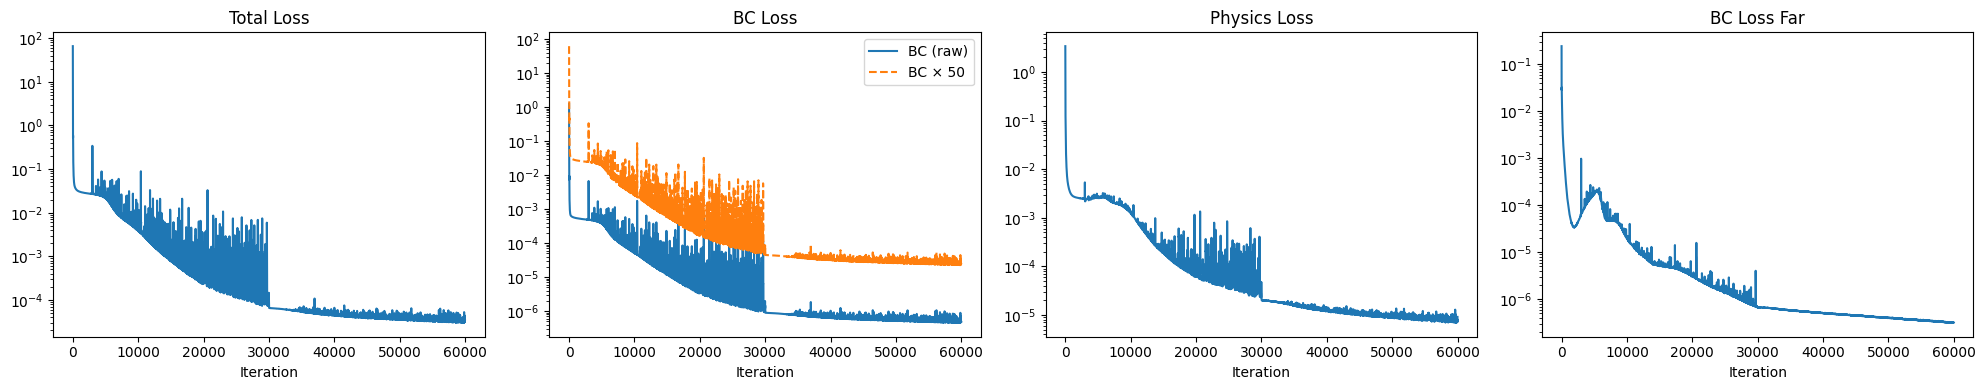


Final BC loss (raw):  4.971524e-07
Final BC loss (×50):  2.485762e-05
Final Physics loss:   7.242927e-06
Ratio physics/BC×50:  0.3


In [3]:
# --- 1. Loss curves (downsampled to every 100th point) ---
step = 10
iters = np.arange(0, len(losses), step)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].semilogy(iters, [float(losses[i]) for i in iters])
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Iteration')

axes[1].semilogy(iters, [float(losses_bc_core[i]) for i in iters], label='BC (raw)')
axes[1].semilogy(iters, [50*float(losses_bc_core[i]) for i in iters], label='BC × 50', linestyle='--')
axes[1].set_title('BC Loss')
axes[1].legend()
axes[1].set_xlabel('Iteration')

axes[2].semilogy(iters, [float(losses_phys[i]) for i in iters])
axes[2].set_title('Physics Loss')
axes[2].set_xlabel('Iteration')

axes[3].semilogy(iters, [float(losses_bc_far[i]) for i in iters])
axes[3].set_title('BC Loss Far')
axes[3].set_xlabel('Iteration')

plt.tight_layout()
plt.show()

# Print final magnitudes so we can see the balance
print(f"\nFinal BC loss (raw):  {float(losses_bc_core[-1]):.6e}")
print(f"Final BC loss (×50):  {50*float(losses_bc_core[-1]):.6e}")
print(f"Final Physics loss:   {float(losses_phys[-1]):.6e}")
print(f"Ratio physics/BC×50:  {float(losses_phys[-1])/(50*float(losses_bc_core[-1])):.1f}")

Radial structure

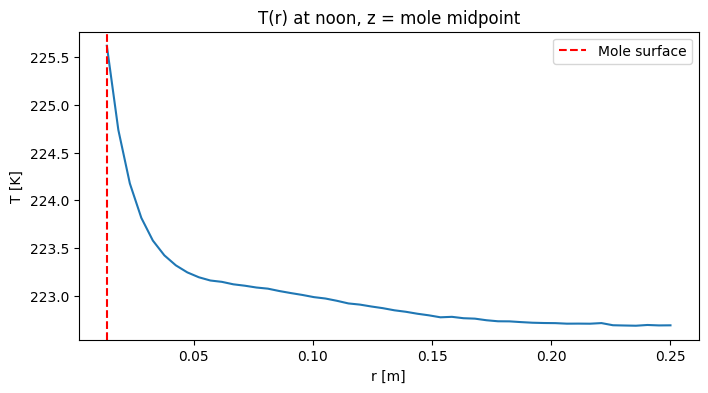

In [4]:
# --- 2. Quick spatial sanity check: does T vary with r? ---
# Evaluate at noon (t=0.5 normalized), several r values, z=mole depth
r_test = jnp.linspace(0, 1, 50).reshape(-1, 1)  # normalized r
t_noon = jnp.ones_like(r_test) * 0.5
z_mole_mid = jnp.ones_like(r_test) * normalize_x((z_0 + z_1) / 2)

txr_test = jnp.concatenate([t_noon, z_mole_mid, r_test], axis=1)
T_pred = unnormalize_u(network(params, txr_test))

plt.figure(figsize=(8, 4))
plt.plot(np.array(r_test * (r_max - R_mole) + R_mole), np.array(T_pred))
plt.xlabel('r [m]')
plt.ylabel('T [K]')
plt.title('T(r) at noon, z = mole midpoint')
plt.axvline(R_mole, color='r', linestyle='--', label='Mole surface')
plt.legend()
plt.show()

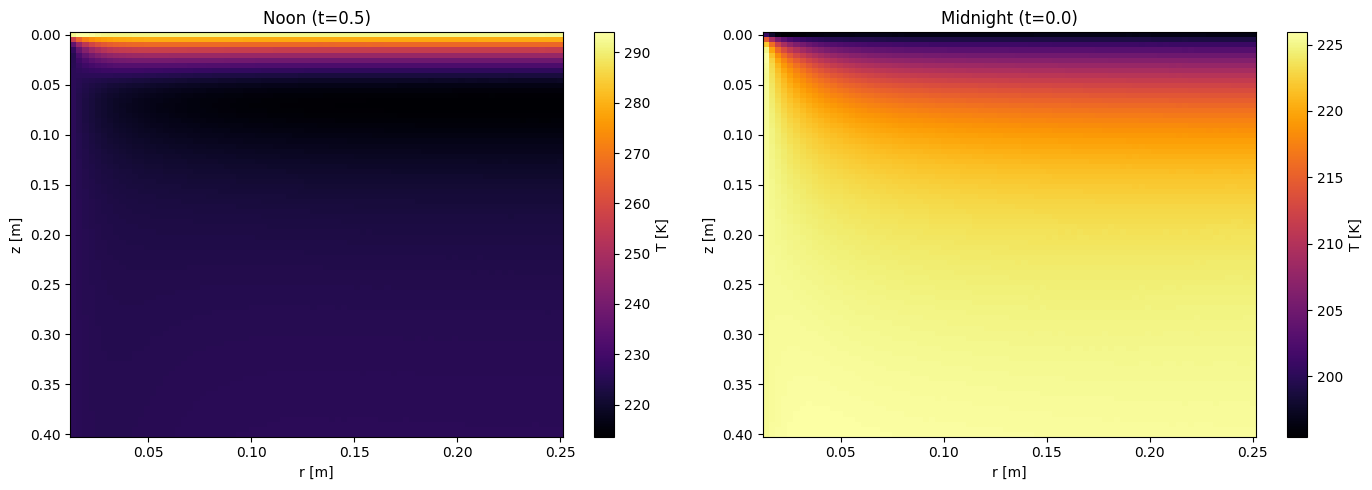

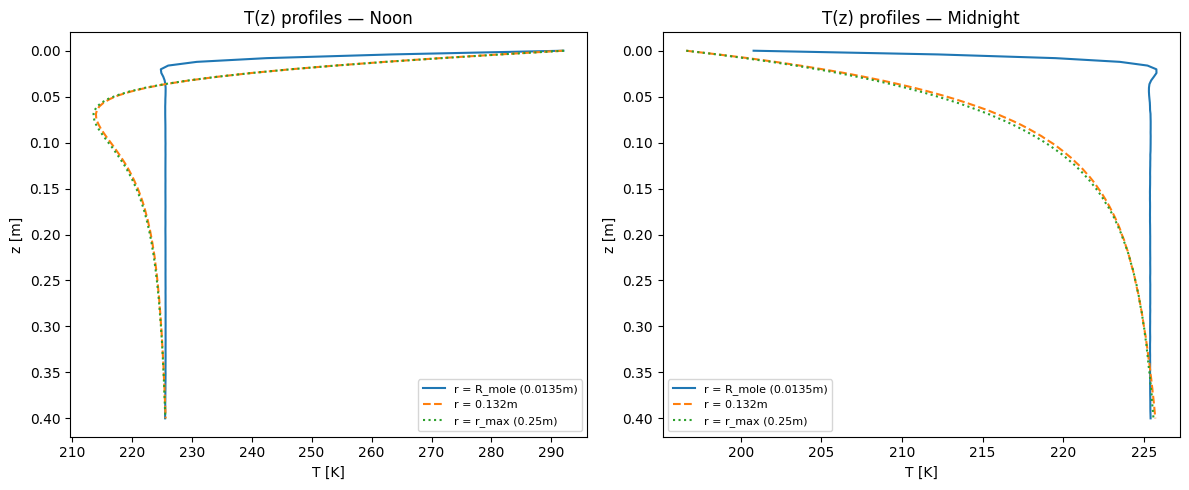

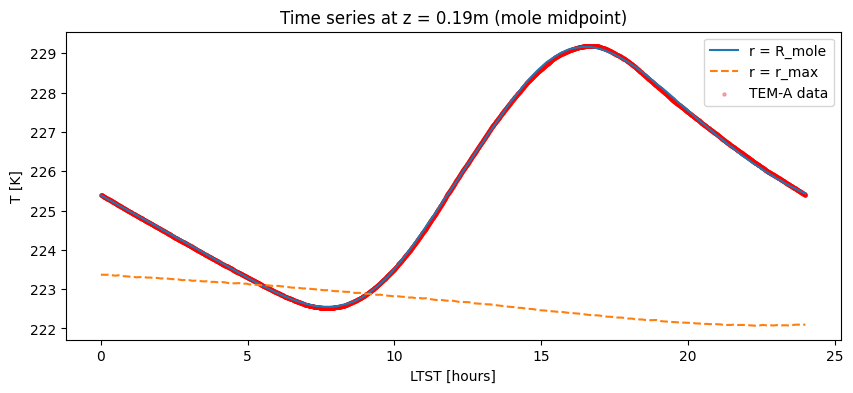

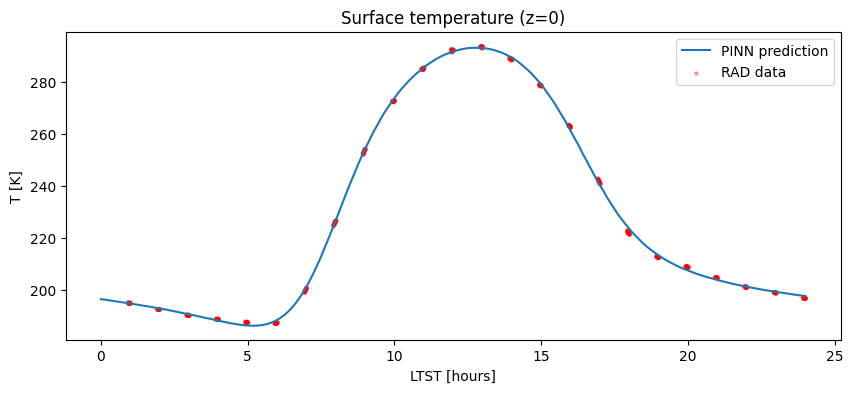

In [5]:
# --- 1. T(r,z) heatmap at noon and midnight ---
nr, nz = 80, 80
r_grid = jnp.linspace(0, 1, nr)
z_grid = jnp.linspace(0, 1, nz)
R_grid, Z_grid = jnp.meshgrid(r_grid, z_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t_val, label in zip(axes, [0.5, 0.0], ['Noon (t=0.5)', 'Midnight (t=0.0)']):
    T_vals = jnp.full_like(R_grid, t_val)
    txr = jnp.stack([T_vals.ravel(), Z_grid.ravel(), R_grid.ravel()], axis=1)
    T_pred = unnormalize_u(network(params, txr)).reshape(nz, nr)

    r_phys = np.array(R_grid * (r_max - R_mole) + R_mole)
    z_phys = np.array(Z_grid * z_max)

    im = ax.pcolormesh(r_phys, z_phys, np.array(T_pred), cmap='inferno', shading='auto')
    ax.set_xlabel('r [m]')
    ax.set_ylabel('z [m]')
    ax.set_title(label)
    ax.invert_yaxis()  # surface at top
    plt.colorbar(im, ax=ax, label='T [K]')
plt.tight_layout()
plt.show()

# --- 2. T(z) profiles: mole vs far-field ---
z_line = jnp.linspace(0, 1, 100).reshape(-1, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, t_val, label in zip(axes, [0.5, 0.0], ['Noon', 'Midnight']):
    for r_val, style, name in [(0.0, '-', f'r = R_mole ({R_mole}m)'),
                                (0.5, '--', f'r = {R_mole + 0.5*(r_max-R_mole):.3f}m'),
                                (1.0, ':', f'r = r_max ({r_max}m)')]:
        t_in = jnp.ones_like(z_line) * t_val
        r_in = jnp.ones_like(z_line) * r_val
        txr = jnp.concatenate([t_in, z_line, r_in], axis=1)
        T_pred = unnormalize_u(network(params, txr))
        ax.plot(np.array(T_pred), np.array(z_line * z_max), style, label=name)

    ax.set_xlabel('T [K]')
    ax.set_ylabel('z [m]')
    ax.set_title(f'T(z) profiles — {label}')
    ax.invert_yaxis()
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- 3. Time series at mole surface vs far-field at mole depth ---
t_line = jnp.linspace(0, 1, 200).reshape(-1, 1)
z_mole_norm = normalize_x((z_0 + z_1) / 2)

fig, ax = plt.subplots(figsize=(10, 4))
for r_val, style, name in [(0.0, '-', 'r = R_mole'), (1.0, '--', 'r = r_max')]:
    z_in = jnp.ones_like(t_line) * z_mole_norm
    r_in = jnp.ones_like(t_line) * r_val
    txr = jnp.concatenate([t_line, z_in, r_in], axis=1)
    T_pred = unnormalize_u(network(params, txr))
    ax.plot(np.array(t_line * 24), np.array(T_pred), style, label=name)

# Overlay actual mole data
ax.scatter(np.array(jnp.array(ltst_mole) * 24 / sol_seconds), temp_mole,
           s=5, alpha=0.3, c='red', label='TEM-A data')
ax.set_xlabel('LTST [hours]')
ax.set_ylabel('T [K]')
ax.set_title(f'Time series at z = {(z_0+z_1)/2:.2f}m (mole midpoint)')
ax.legend()
plt.show()

# --- 4. Surface temperature check ---
fig, ax = plt.subplots(figsize=(10, 4))
z_in = jnp.zeros_like(t_line)
r_in = jnp.ones_like(t_line) * 0.5  # mid-domain r
txr = jnp.concatenate([t_line, z_in, r_in], axis=1)
T_pred_surf = unnormalize_u(network(params, txr))
ax.plot(np.array(t_line * 24), np.array(T_pred_surf), label='PINN prediction')
ax.scatter(np.array(jnp.array(ltst_surf) * 24 / sol_seconds), temp_surf,
           s=5, alpha=0.3, c='red', label='RAD data')
ax.set_xlabel('LTST [hours]')
ax.set_ylabel('T [K]')
ax.set_title('Surface temperature (z=0)')
ax.legend()
plt.show()

## k parameter sweep

In [9]:
# Test a range of kappa values
kappa_candidates = jnp.logspace(-8.5, -6.5, 15)  # 15 values from ~3e-9 to ~3e-7

results = []

for idx, kappa_test in enumerate(kappa_candidates):
    # Fresh network each time
    key = random.PRNGKey(idx)
    params_sweep = init_network_params(layer_sizes, key)

    # Fix kappa — not learnable
    kappa_fixed = float(kappa_test)

    opt_state_sweep = optimizer.init(params_sweep)

    # Short training — 20k iterations is enough to see the trend
    for i in range(20000):
        params_sweep, opt_state_sweep, loss, aux = update_step(
            params_sweep, opt_state_sweep,
            t_bc, x_bc, r_bc, u_bc,
            t_bc_far, x_bc_far,
            t_physics, x_physics, r_physics,
            kappa_fixed)

    results.append({
        'kappa': float(kappa_test),
        'total_loss': float(loss),
        'bc_core': float(aux[0]),
        'physics': float(aux[1]),
        'bc_far': float(aux[2])
    })
    print(f"[{idx+1}/15] κ = {float(kappa_test):.3e}, "
          f"Total: {float(loss):.6f}, BC: {float(aux[0]):.3e}, "
          f"Phys: {float(aux[1]):.3e}")

[1/15] κ = 3.162e-09, Total: 0.000170, BC: 2.358e-06, Phys: 5.043e-05
[2/15] κ = 4.394e-09, Total: 0.000198, BC: 2.689e-06, Phys: 6.217e-05
[3/15] κ = 6.105e-09, Total: 0.000255, BC: 3.182e-06, Phys: 9.363e-05
[4/15] κ = 8.483e-09, Total: 0.000104, BC: 1.413e-06, Phys: 3.196e-05
[5/15] κ = 1.179e-08, Total: 0.000410, BC: 7.377e-06, Phys: 4.047e-05
[6/15] κ = 1.638e-08, Total: 0.000449, BC: 8.296e-06, Phys: 3.346e-05
[7/15] κ = 2.276e-08, Total: 0.000413, BC: 6.141e-06, Phys: 1.033e-04
[8/15] κ = 3.162e-08, Total: 0.000310, BC: 4.360e-06, Phys: 8.944e-05
[9/15] κ = 4.394e-08, Total: 0.000214, BC: 2.984e-06, Phys: 6.136e-05
[10/15] κ = 6.105e-08, Total: 0.000584, BC: 8.057e-06, Phys: 1.793e-04
[11/15] κ = 8.483e-08, Total: 0.001891, BC: 3.154e-05, Phys: 3.116e-04
[12/15] κ = 1.179e-07, Total: 0.000500, BC: 7.671e-06, Phys: 1.135e-04
[13/15] κ = 1.638e-07, Total: 0.000733, BC: 1.069e-05, Phys: 1.948e-04
[14/15] κ = 2.276e-07, Total: 0.003633, BC: 6.626e-05, Phys: 3.167e-04
[15/15] κ = 3.1

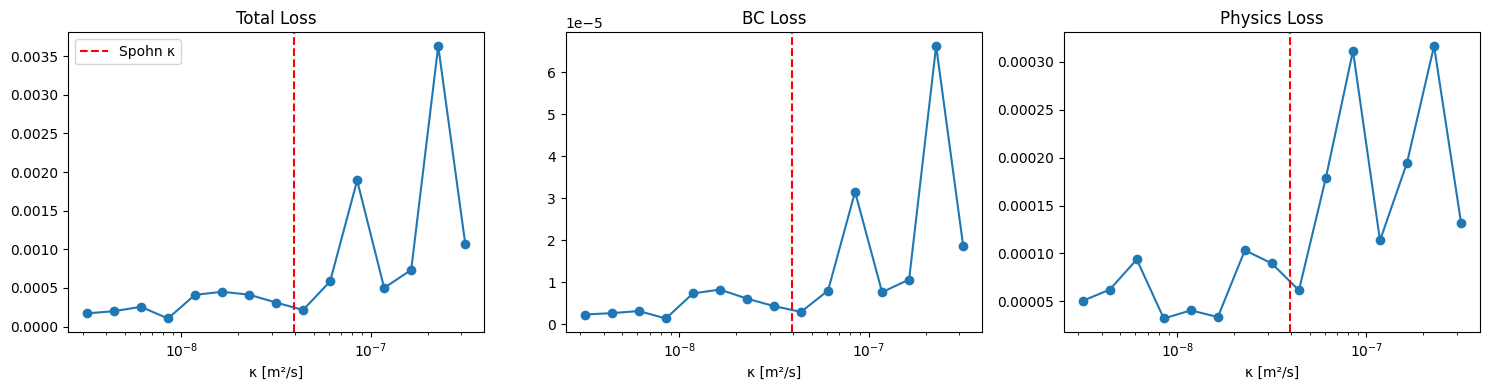


Best κ:   8.483e-09
Spohn κ:  3.93e-8
Ratio:    0.22x


In [10]:
kappas = [r['kappa'] for r in results]
total_losses = [r['total_loss'] for r in results]
bc_losses = [r['bc_core'] for r in results]
phys_losses = [r['physics'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogx(kappas, total_losses, 'o-')
axes[0].axvline(3.93e-8, color='r', linestyle='--', label='Spohn κ')
axes[0].set_xlabel('κ [m²/s]')
axes[0].set_title('Total Loss')
axes[0].legend()

axes[1].semilogx(kappas, bc_losses, 'o-')
axes[1].axvline(3.93e-8, color='r', linestyle='--')
axes[1].set_xlabel('κ [m²/s]')
axes[1].set_title('BC Loss')

axes[2].semilogx(kappas, phys_losses, 'o-')
axes[2].axvline(3.93e-8, color='r', linestyle='--')
axes[2].set_xlabel('κ [m²/s]')
axes[2].set_title('Physics Loss')

plt.tight_layout()
plt.show()

# Find the best kappa
best = min(results, key=lambda r: r['total_loss'])
print(f"\nBest κ:   {best['kappa']:.3e}")
print(f"Spohn κ:  3.93e-8")
print(f"Ratio:    {best['kappa']/3.93e-8:.2f}x")

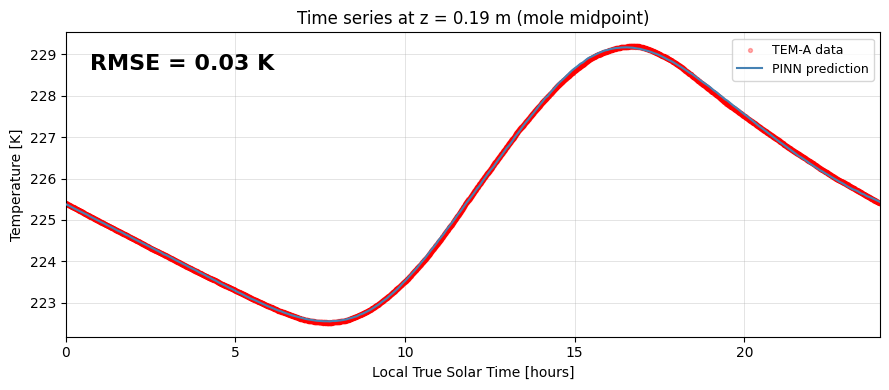

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

# Datos primero, semitransparentes
ax.scatter(ltst_mole_hours, temp_mole,
           color='red', alpha=0.3,
           s=8, zorder=2, label='TEM-A data')

# PINN encima, línea más visible
ax.plot(t_hours, T_pred_mole,
        color='steelblue', lw=1.5,
        zorder=5, label='PINN prediction')

ax.text(0.03, 0.93, f'RMSE = {rmse_mole:.2f} K',
        transform=ax.transAxes,
        fontsize=16, fontweight='bold', color='black',
        va='top', ha='left')

ax.set_xlabel('Local True Solar Time [hours]')
ax.set_ylabel('Temperature [K]')
ax.set_title(f'Time series at z = {z_target:.2f} m (mole midpoint)')
ax.legend(fontsize=9)
ax.set_xlim(0, 24)
ax.grid(True, linewidth=0.4, alpha=0.6)

fig.tight_layout()
plt.savefig('timeseries_z019_rmse.png', dpi=150)
plt.show()